In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
import warnings
warnings.filterwarnings("ignore")


In [46]:
df = pd.read_csv("/content/student-por.csv")

In [47]:
print(df.head())
print(df.info())
print(df.shape)
print(df.describe())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (to

In [48]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


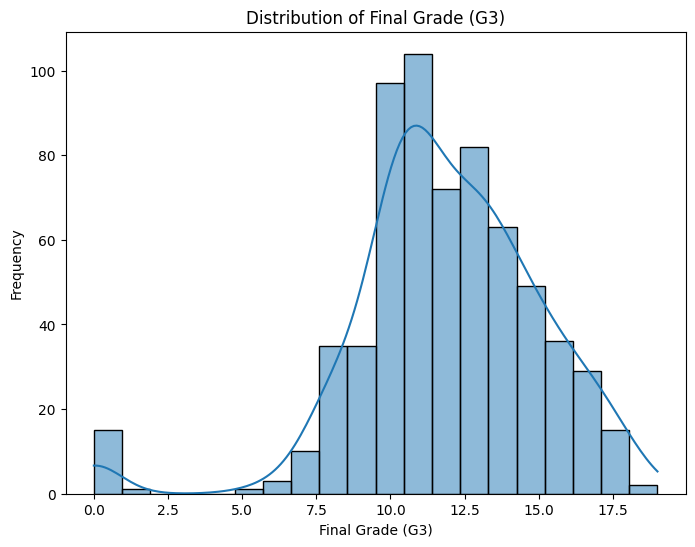

In [49]:
plt.figure(figsize=(8, 6))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title('Distribution of Final Grade (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

### Explanation of Column Names

Here are the meanings of the columns you asked about, based on typical student performance datasets:

*   **`Walc`**: Weekly alcohol consumption (numeric from 1 to 5: very low to very high)
*   **`Dalc`**: Daily alcohol consumption (numeric from 1 to 5: very low to very high)
*   **`goout`**: Going out with friends (numeric from 1 to 5: very low to very high)
*   **`famrel`**: Quality of family relationships (numeric from 1 to 5: very bad to excellent)
*   **`famsup`**: Family educational support (binary: yes or no)
*   **`schoolsup`**: Extra educational support (binary: yes or no)
*   **`Fedu`**: Father's education (numeric from 0 to 4: none to higher education)
*   **`Mjob`**: Mother's job (nominal: 'teacher', 'health', 'services', 'at_home', 'other')
*   **`Fjob`**: Father's job (nominal: 'teacher', 'health', 'services', 'at_home', 'other')
*   **`famsize`**: Family size (binary: 'LE3' - less or equal to 3, 'GT3' - greater than 3)
*   **`Pstatus`**: Parent's cohabitation status (binary: 'T' - living together, 'A' - apart)
*   **`Medu`**: Mother's education (numeric from 0 to 4: none to higher education)

### Exploring Relationships with G3 (Final Grade)

We will now visualize the relationship between the final grade (`G3`) and the first five columns of the dataset: `school`, `sex`, `age`, `address`, and `famsize`.

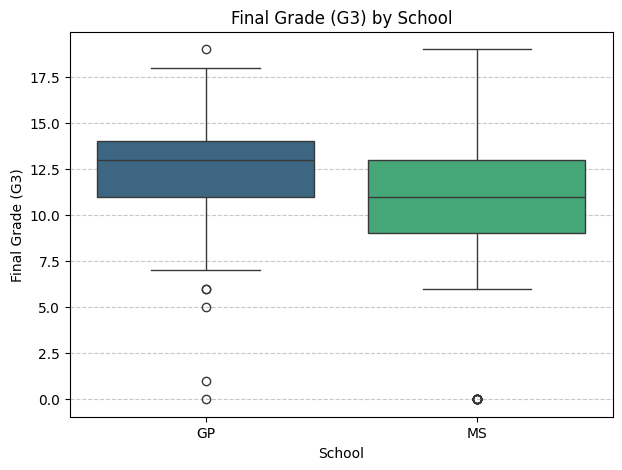

In [50]:
# Relationship between School and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='school', y='G3', data=df, palette='viridis')
plt.title('Final Grade (G3) by School')
plt.xlabel('School')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

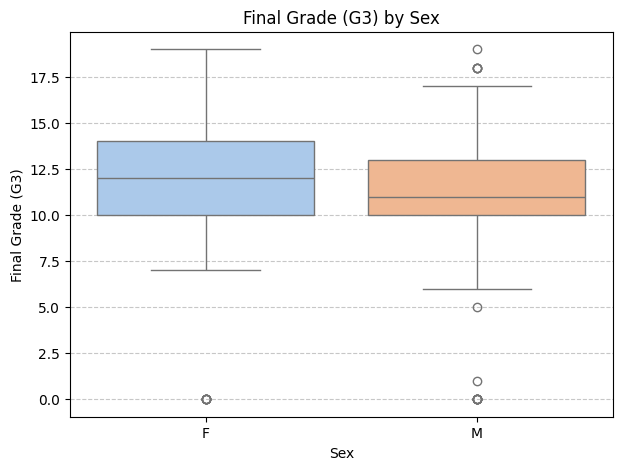

In [51]:
# Relationship between Sex and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='sex', y='G3', data=df, palette='pastel')
plt.title('Final Grade (G3) by Sex')
plt.xlabel('Sex')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

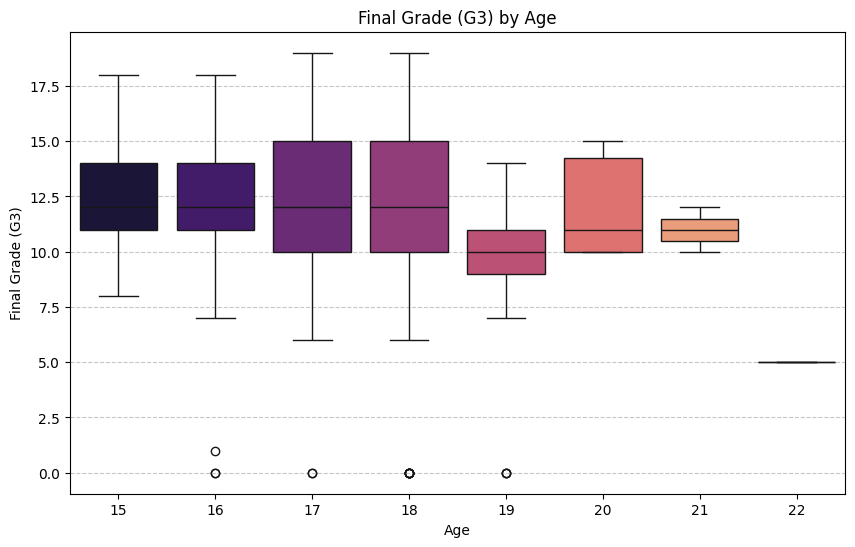

In [52]:
# Relationship between Age and G3
plt.figure(figsize=(10, 6))
sns.boxplot(x='age', y='G3', data=df, palette='magma')
plt.title('Final Grade (G3) by Age')
plt.xlabel('Age')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

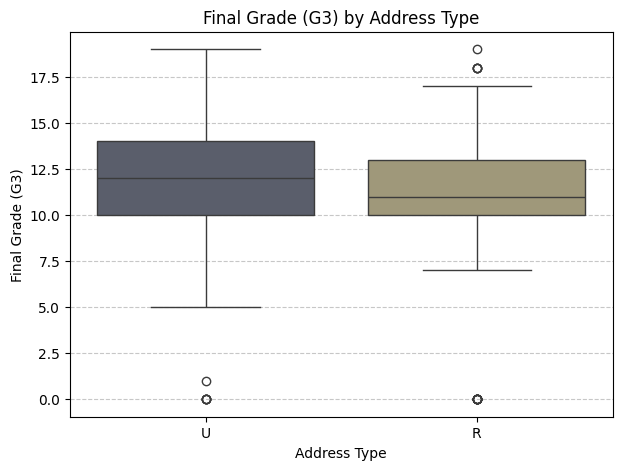

In [53]:
# Relationship between Address and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='address', y='G3', data=df, palette='cividis')
plt.title('Final Grade (G3) by Address Type')
plt.xlabel('Address Type')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

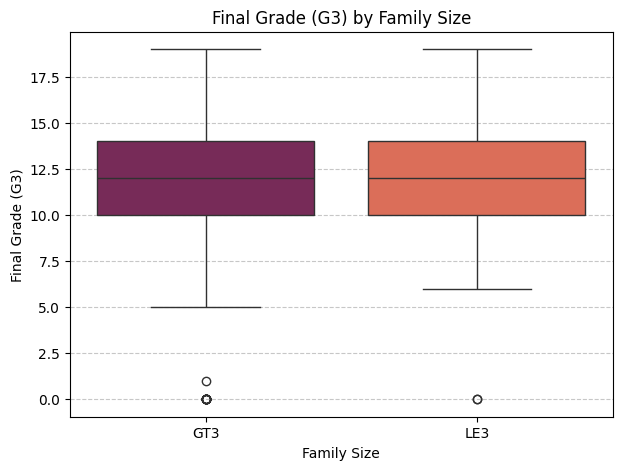

In [54]:
# Relationship between Family Size and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='famsize', y='G3', data=df, palette='rocket')
plt.title('Final Grade (G3) by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Exploring Relationships with G3 (Final Grade) - Part 2

Continuing our exploration, we will now visualize the relationship between the final grade (`G3`) and the next set of columns: `Pstatus`, `Medu`, `Fedu`, `Mjob`, and `Fjob`.

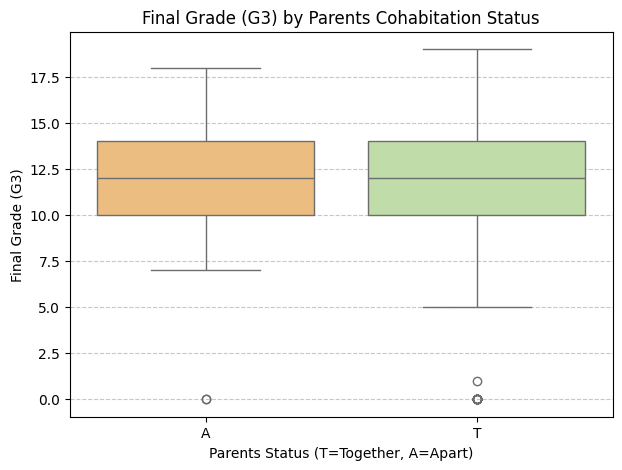

In [55]:
# Relationship between Pstatus and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='Pstatus', y='G3', data=df, palette='Spectral')
plt.title('Final Grade (G3) by Parents Cohabitation Status')
plt.xlabel('Parents Status (T=Together, A=Apart)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

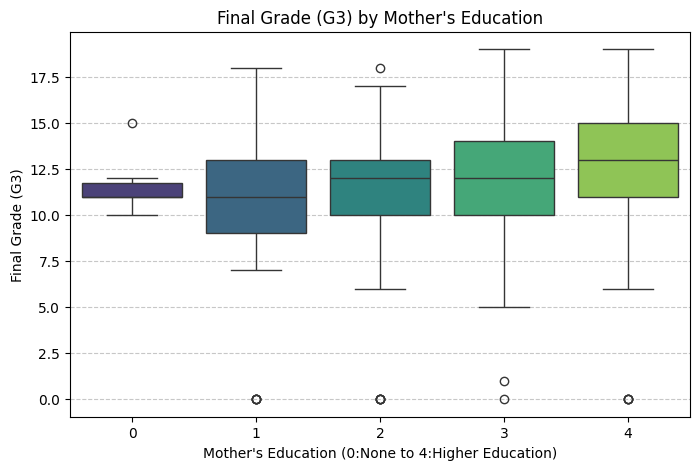

In [56]:
# Relationship between Medu (Mother's Education) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='Medu', y='G3', data=df, palette='viridis')
plt.title('Final Grade (G3) by Mother\'s Education')
plt.xlabel('Mother\'s Education (0:None to 4:Higher Education)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

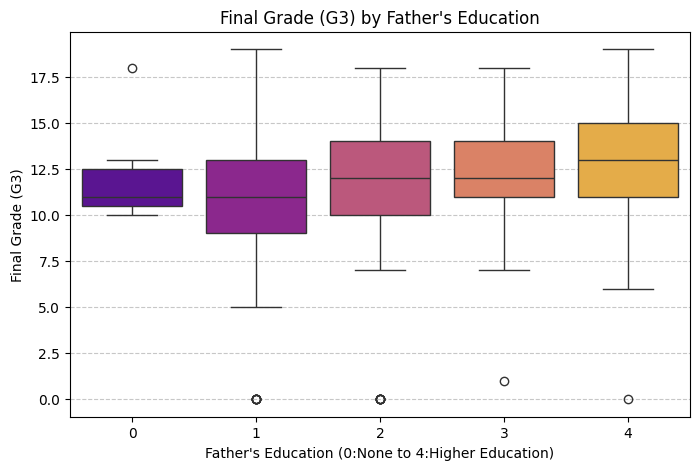

In [57]:
# Relationship between Fedu (Father's Education) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fedu', y='G3', data=df, palette='plasma')
plt.title('Final Grade (G3) by Father\'s Education')
plt.xlabel('Father\'s Education (0:None to 4:Higher Education)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

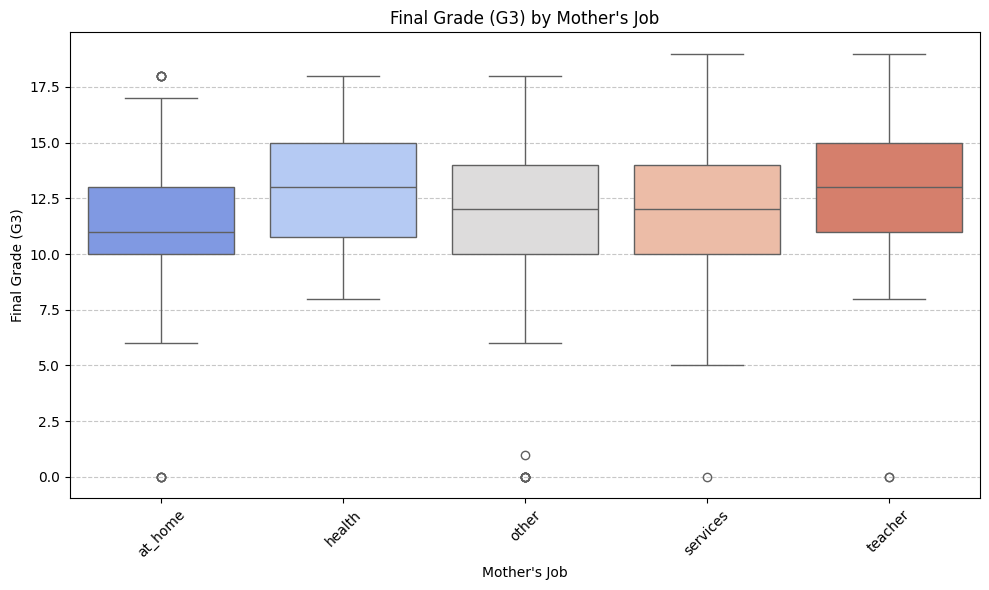

In [58]:
# Relationship between Mjob (Mother's Job) and G3
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mjob', y='G3', data=df, palette='coolwarm')
plt.title('Final Grade (G3) by Mother\'s Job')
plt.xlabel('Mother\'s Job')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

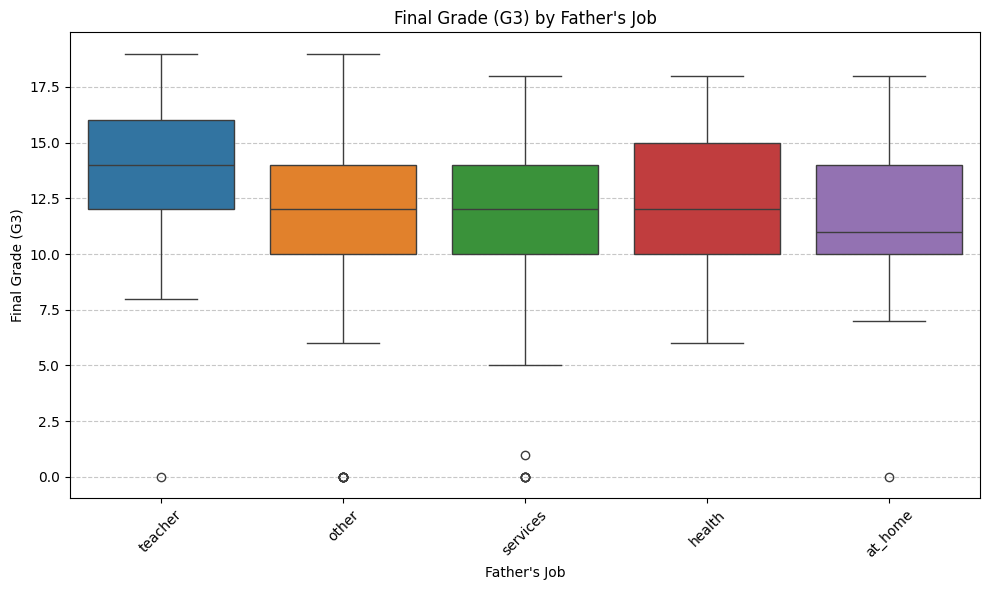

In [59]:
# Relationship between Fjob (Father's Job) and G3
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fjob', y='G3', data=df, palette='tab10')
plt.title('Final Grade (G3) by Father\'s Job')
plt.xlabel('Father\'s Job')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exploring Relationships with G3 (Final Grade) - Part 3

We will now visualize the relationship between the final grade (`G3`) and the next set of columns: `reason`, `guardian`, `traveltime`, `studytime`, and `failures`.

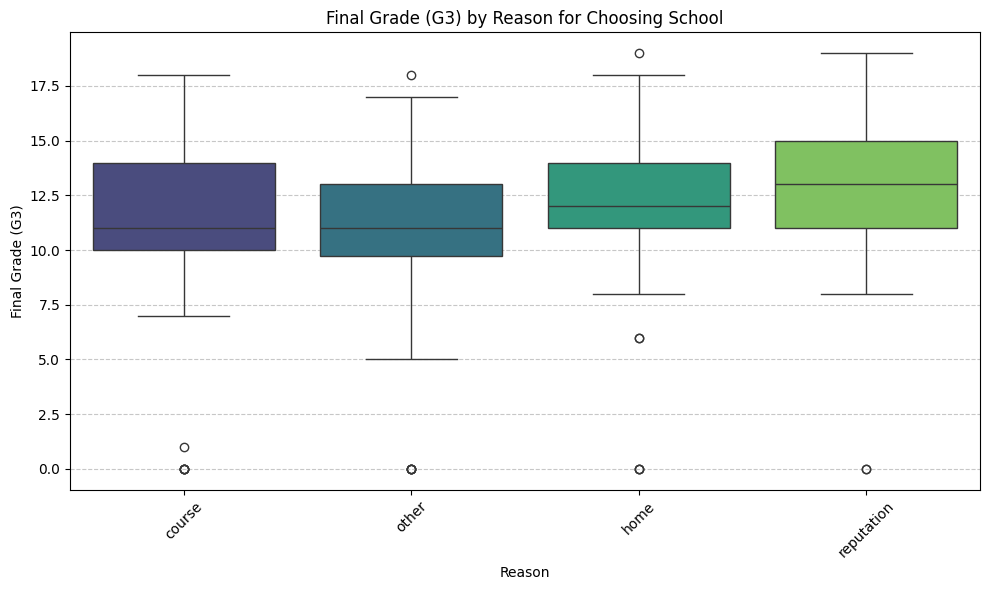

In [60]:
# Relationship between Reason and G3
plt.figure(figsize=(10, 6))
sns.boxplot(x='reason', y='G3', data=df, palette='viridis')
plt.title('Final Grade (G3) by Reason for Choosing School')
plt.xlabel('Reason')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

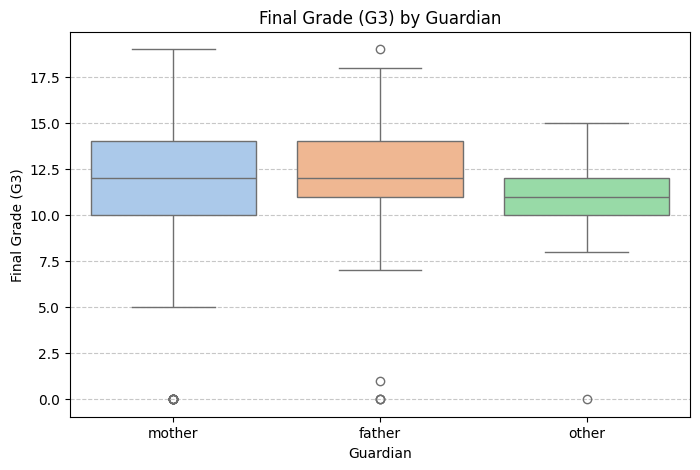

In [61]:
# Relationship between Guardian and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='guardian', y='G3', data=df, palette='pastel')
plt.title('Final Grade (G3) by Guardian')
plt.xlabel('Guardian')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

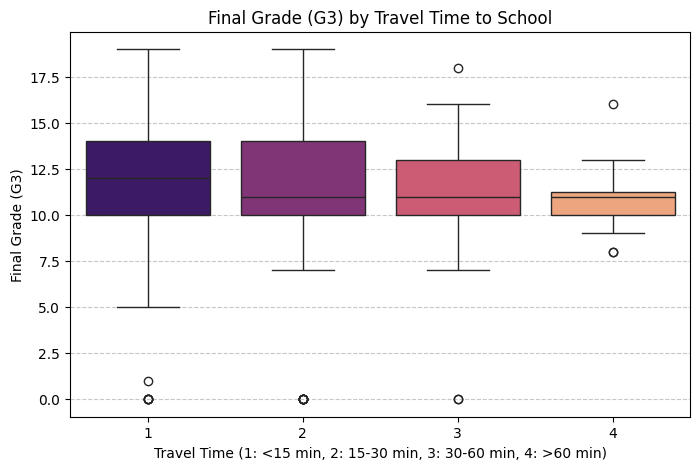

In [62]:
# Relationship between Traveltime and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='traveltime', y='G3', data=df, palette='magma')
plt.title('Final Grade (G3) by Travel Time to School')
plt.xlabel('Travel Time (1: <15 min, 2: 15-30 min, 3: 30-60 min, 4: >60 min)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

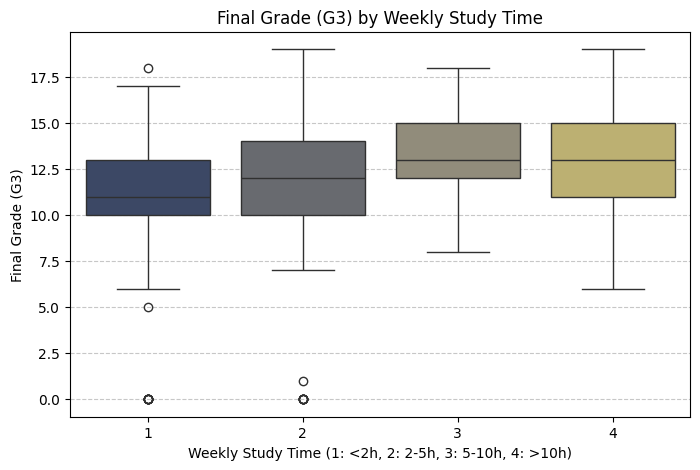

In [63]:
# Relationship between Studytime and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='studytime', y='G3', data=df, palette='cividis')
plt.title('Final Grade (G3) by Weekly Study Time')
plt.xlabel('Weekly Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

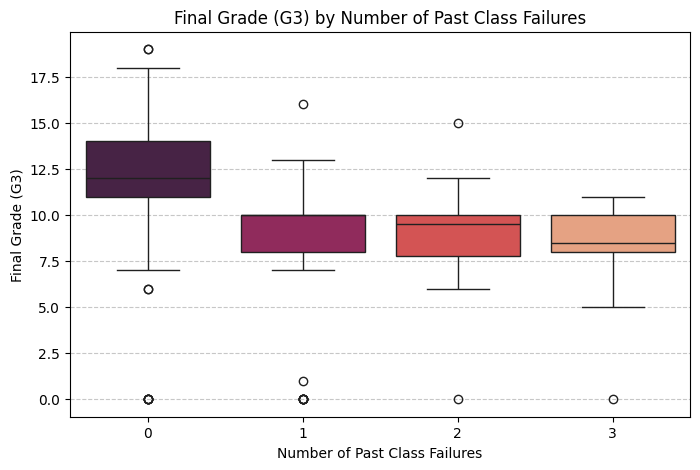

In [64]:
# Relationship between Failures and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='failures', y='G3', data=df, palette='rocket')
plt.title('Final Grade (G3) by Number of Past Class Failures')
plt.xlabel('Number of Past Class Failures')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Exploring Relationships with G3 (Final Grade) - Part 5

We will now visualize the relationship between the final grade (`G3`) and the next set of columns: `higher`, `internet`, `romantic`, `famrel`, and `freetime`.

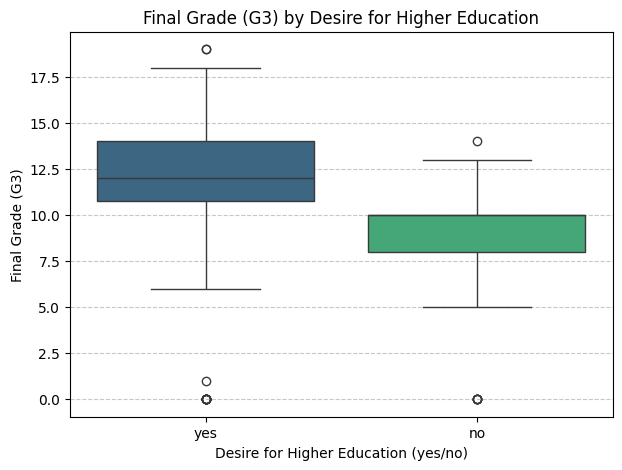

In [65]:
# Relationship between higher (Wants to take higher education) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='higher', y='G3', data=df, palette='viridis')
plt.title('Final Grade (G3) by Desire for Higher Education')
plt.xlabel('Desire for Higher Education (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

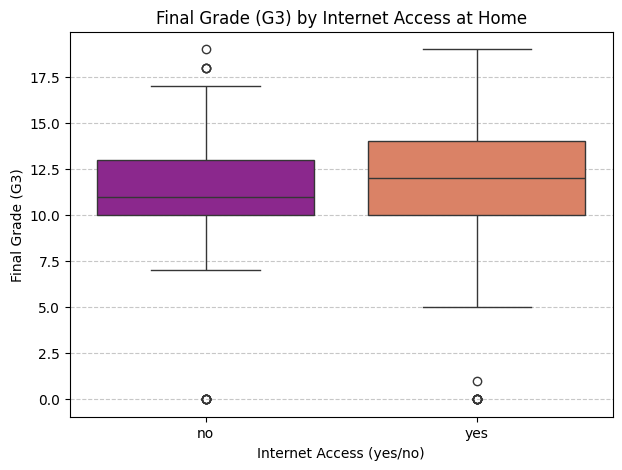

In [66]:
# Relationship between internet (Internet access at home) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='internet', y='G3', data=df, palette='plasma')
plt.title('Final Grade (G3) by Internet Access at Home')
plt.xlabel('Internet Access (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

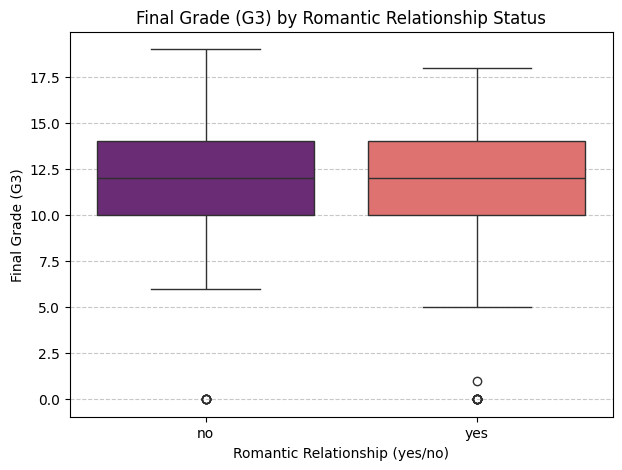

In [67]:
# Relationship between romantic (In a romantic relationship) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='romantic', y='G3', data=df, palette='magma')
plt.title('Final Grade (G3) by Romantic Relationship Status')
plt.xlabel('Romantic Relationship (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

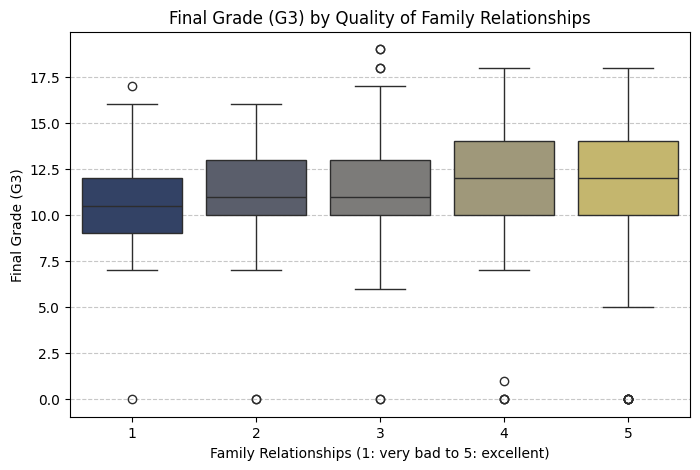

In [68]:
# Relationship between famrel (Quality of family relationships) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='famrel', y='G3', data=df, palette='cividis')
plt.title('Final Grade (G3) by Quality of Family Relationships')
plt.xlabel('Family Relationships (1: very bad to 5: excellent)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

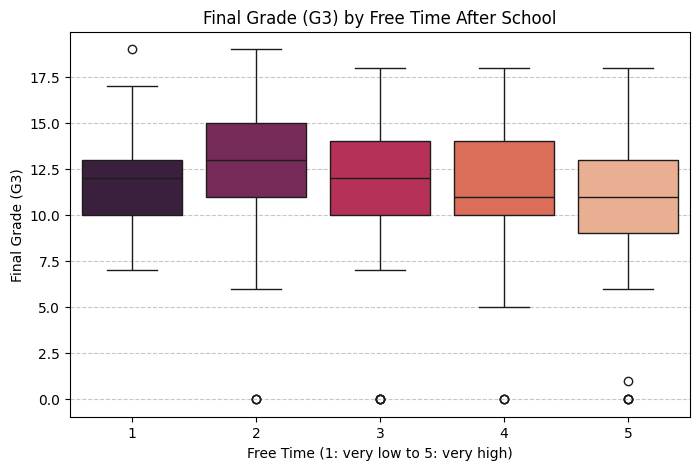

In [69]:
# Relationship between freetime (Free time after school) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='freetime', y='G3', data=df, palette='rocket')
plt.title('Final Grade (G3) by Free Time After School')
plt.xlabel('Free Time (1: very low to 5: very high)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Exploring Relationships with G3 (Final Grade) - Part 6

We will now visualize the relationship between the final grade (`G3`) and the next set of columns: `goout`, `Dalc`, `Walc`, `health`, and `absences`.

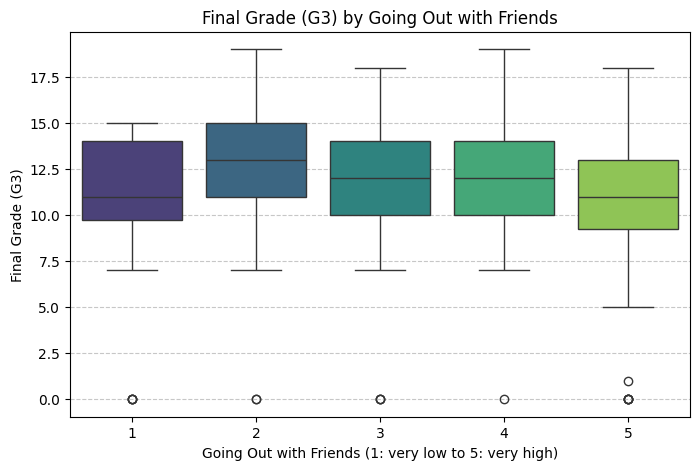

In [70]:
# Relationship between goout (Going out with friends) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='goout', y='G3', data=df, palette='viridis')
plt.title('Final Grade (G3) by Going Out with Friends')
plt.xlabel('Going Out with Friends (1: very low to 5: very high)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

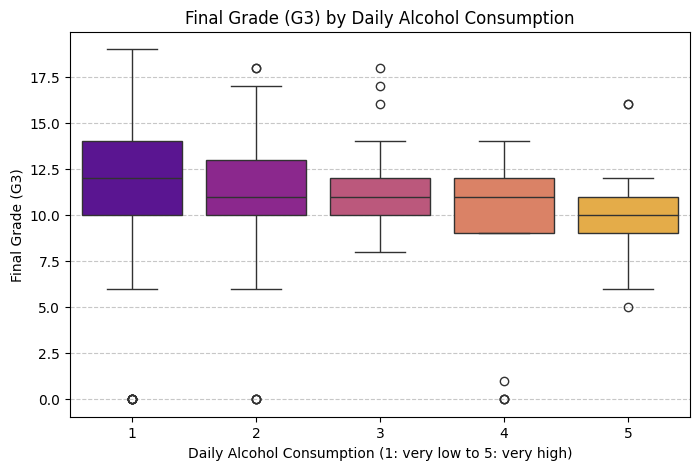

In [71]:
# Relationship between Dalc (Daily alcohol consumption) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dalc', y='G3', data=df, palette='plasma')
plt.title('Final Grade (G3) by Daily Alcohol Consumption')
plt.xlabel('Daily Alcohol Consumption (1: very low to 5: very high)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

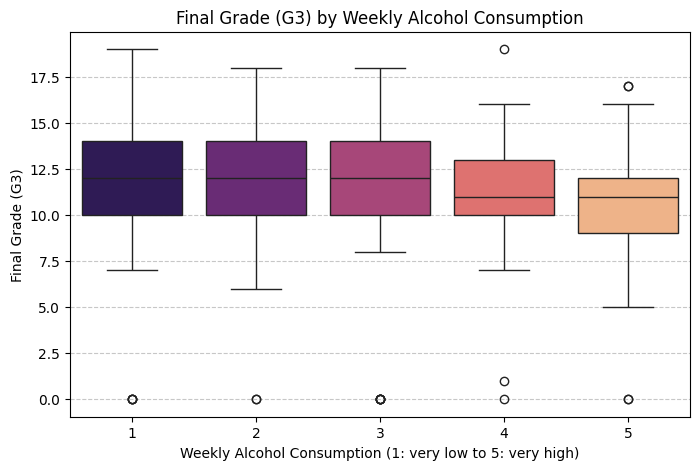

In [72]:
# Relationship between Walc (Weekly alcohol consumption) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='Walc', y='G3', data=df, palette='magma')
plt.title('Final Grade (G3) by Weekly Alcohol Consumption')
plt.xlabel('Weekly Alcohol Consumption (1: very low to 5: very high)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

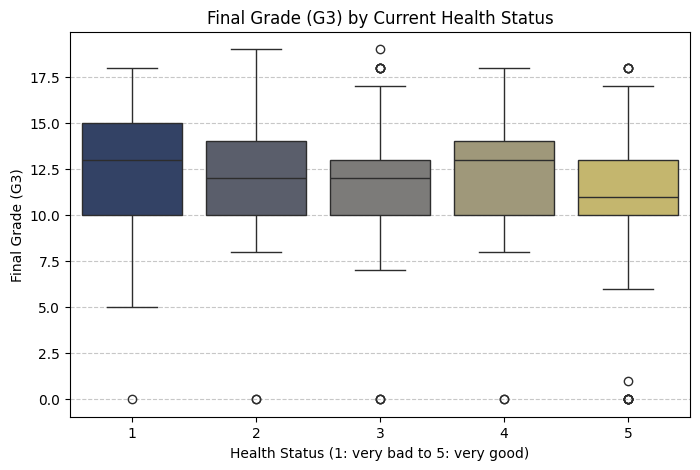

In [73]:
# Relationship between health (Current health status) and G3
plt.figure(figsize=(8, 5))
sns.boxplot(x='health', y='G3', data=df, palette='cividis')
plt.title('Final Grade (G3) by Current Health Status')
plt.xlabel('Health Status (1: very bad to 5: very good)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

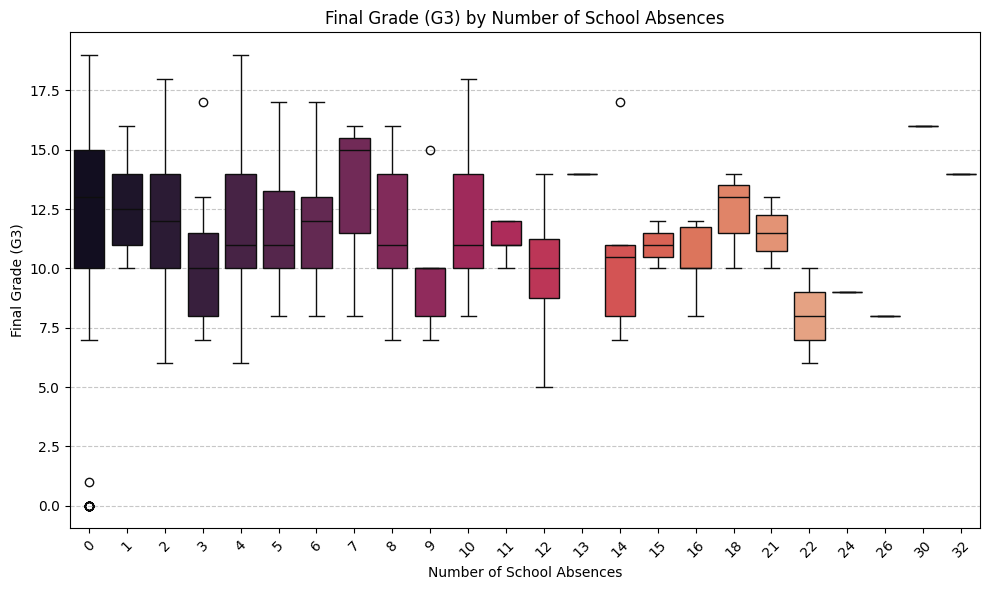

In [74]:
# Relationship between absences (Number of school absences) and G3
plt.figure(figsize=(10, 6))
sns.boxplot(x='absences', y='G3', data=df, palette='rocket')
plt.title('Final Grade (G3) by Number of School Absences')
plt.xlabel('Number of School Absences')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exploring Relationships with G3 (Final Grade) - Part 7

Finally, we will visualize the relationship between the final grade (`G3`) and the intermediate grades: `G1` and `G2`.

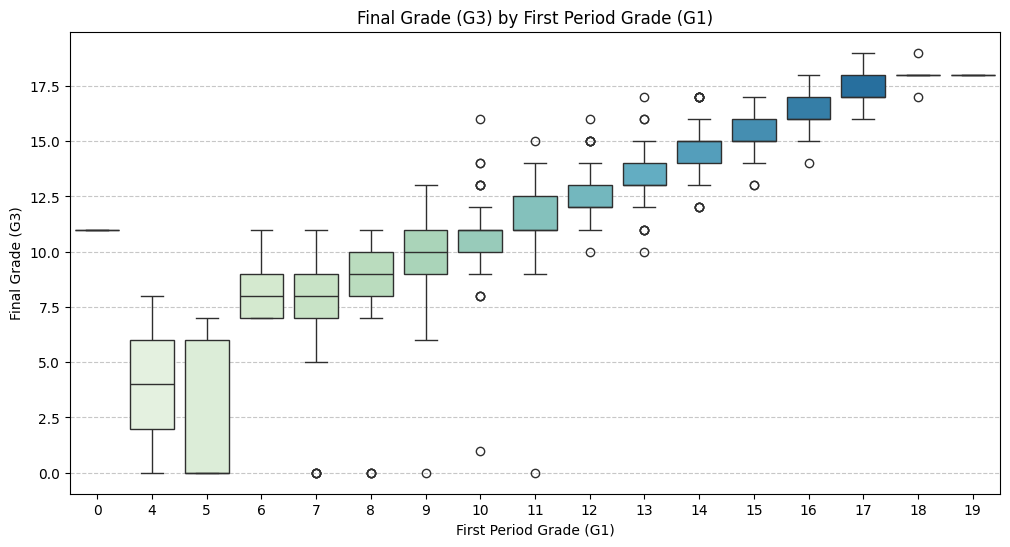

In [75]:
# Relationship between G1 (First Period Grade) and G3
plt.figure(figsize=(12, 6))
sns.boxplot(x='G1', y='G3', data=df, palette='GnBu')
plt.title('Final Grade (G3) by First Period Grade (G1)')
plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

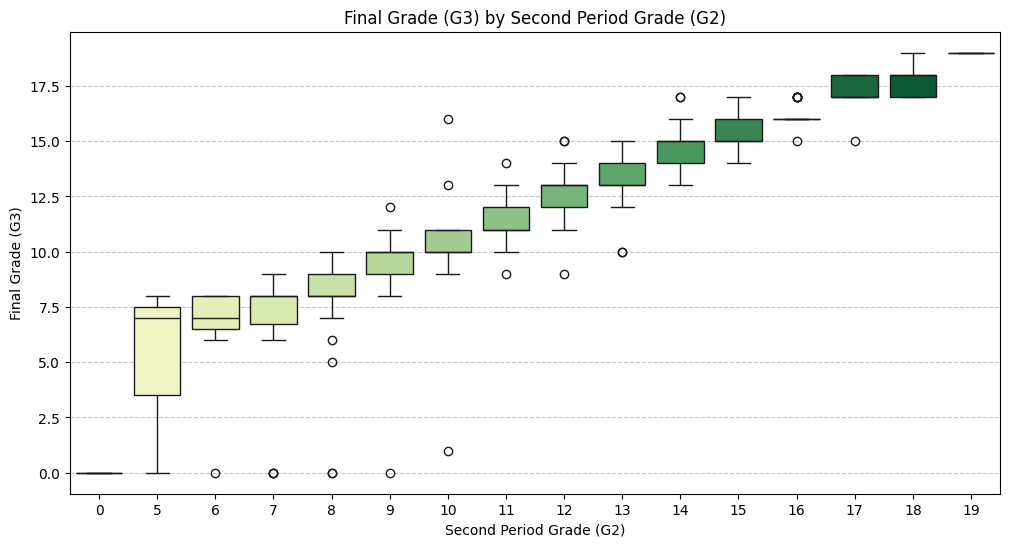

In [76]:
# Relationship between G2 (Second Period Grade) and G3
plt.figure(figsize=(12, 6))
sns.boxplot(x='G2', y='G3', data=df, palette='YlGn')
plt.title('Final Grade (G3) by Second Period Grade (G2)')
plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Exploring Relationships with G3 (Final Grade) - Part 4

We will now visualize the relationship between the final grade (`G3`) and the next set of columns: `schoolsup`, `famsup`, `paid`, `activities`, and `nursery`.

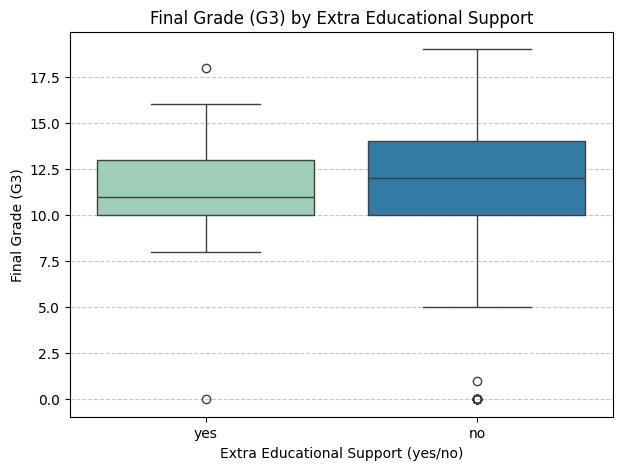

In [77]:
# Relationship between schoolsup (Extra educational support) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='schoolsup', y='G3', data=df, palette='YlGnBu')
plt.title('Final Grade (G3) by Extra Educational Support')
plt.xlabel('Extra Educational Support (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

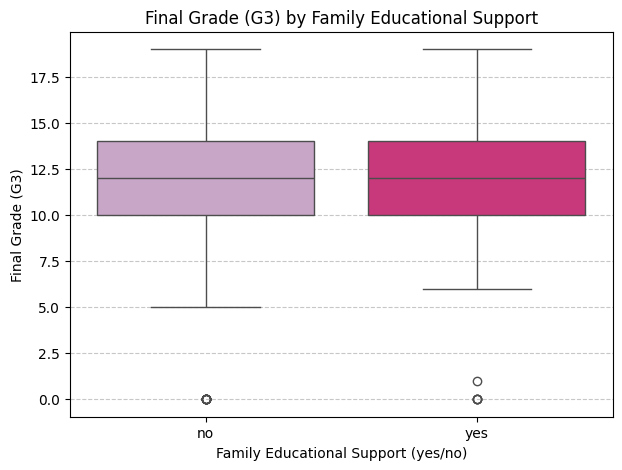

In [78]:
# Relationship between famsup (Family educational support) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='famsup', y='G3', data=df, palette='PuRd')
plt.title('Final Grade (G3) by Family Educational Support')
plt.xlabel('Family Educational Support (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

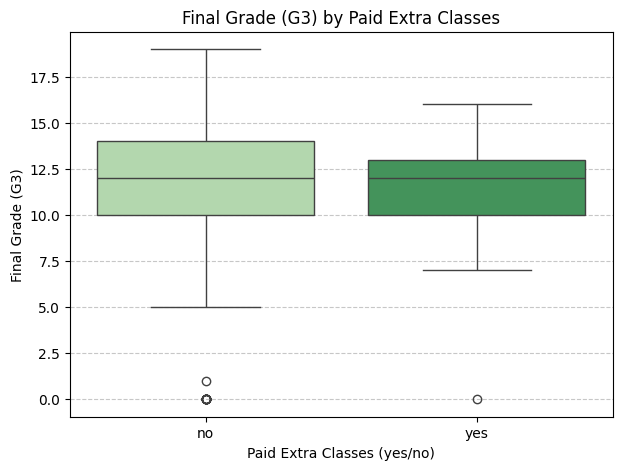

In [79]:
# Relationship between paid (Paid classes) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='paid', y='G3', data=df, palette='Greens')
plt.title('Final Grade (G3) by Paid Extra Classes')
plt.xlabel('Paid Extra Classes (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

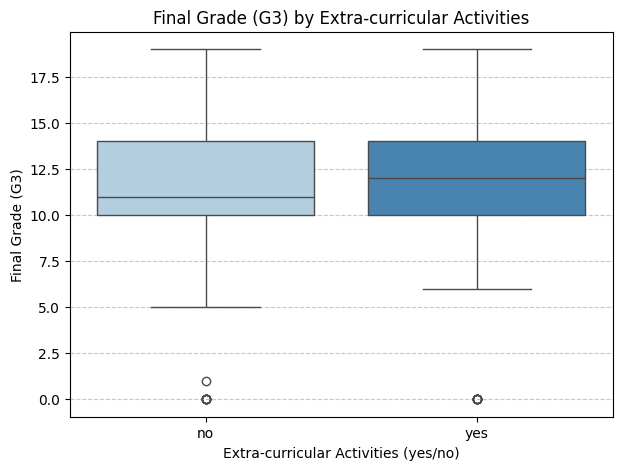

In [80]:
# Relationship between activities (Extra-curricular activities) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='activities', y='G3', data=df, palette='Blues')
plt.title('Final Grade (G3) by Extra-curricular Activities')
plt.xlabel('Extra-curricular Activities (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

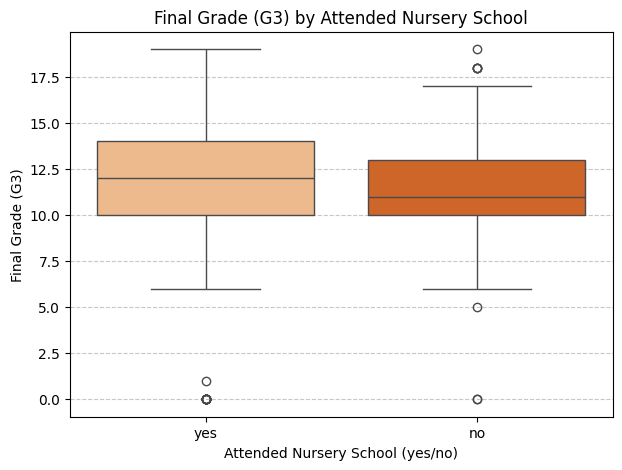

In [81]:
# Relationship between nursery (Attended nursery school) and G3
plt.figure(figsize=(7, 5))
sns.boxplot(x='nursery', y='G3', data=df, palette='Oranges')
plt.title('Final Grade (G3) by Attended Nursery School')
plt.xlabel('Attended Nursery School (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [82]:
df.columns


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [83]:
features = ['age','studytime','failures','absences','G1', 'G2']
target = ["G3"]

x = df[features]
y = df[target]

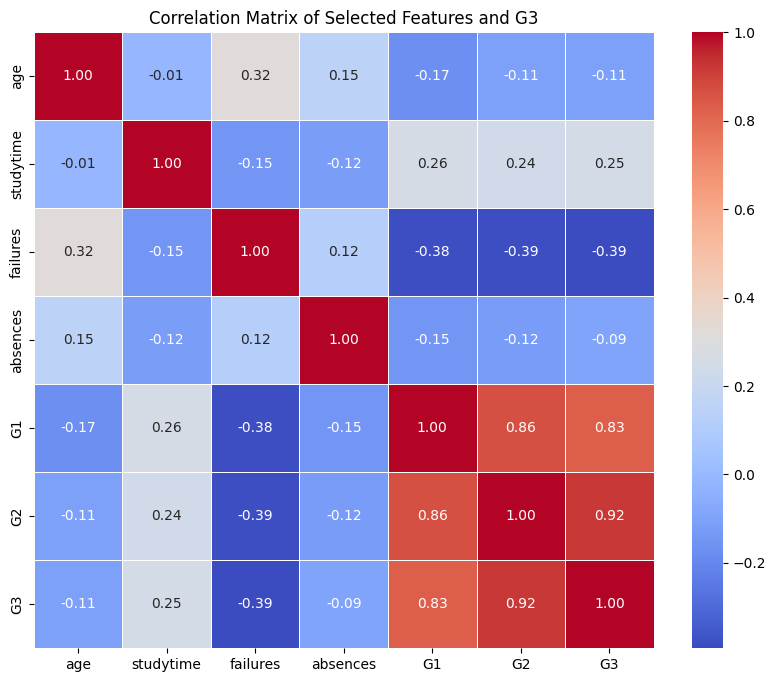

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine features and target into a single DataFrame for correlation calculation
correlation_df = x.copy()
correlation_df['G3'] = y

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Selected Features and G3')
plt.show()

In [85]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error , r2_score

In [86]:
train_test_split()

In [87]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [88]:
model = LinearRegression()
model.fit(X_train,y_train,)

LinearRegression()

In [89]:
y_pred = model.predict(X_test)

In [90]:
r2_score(y_test,y_pred)

0.8634139665476478

In [91]:
mean_squared_error(y_test,y_pred)

1.3319482045610327

In [92]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(1.1541006041767037)

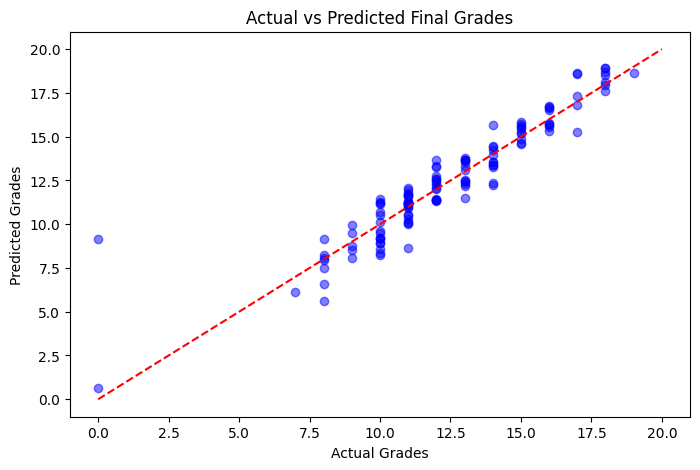

     Feature  Coefficient
5         G2     0.870613
4         G1     0.183680
1  studytime     0.112120
3   absences     0.024670
0        age     0.017845
2   failures    -0.166628


In [96]:
# Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([0,20], [0,20], color='red', linestyle='--')
plt.xlabel('Actual Grades')
plt.ylabel('Predicted Grades')
plt.title('Actual vs Predicted Final Grades')
plt.show()

# Feature importance
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_.flatten() # Flatten the coefficients array
}).sort_values('Coefficient', ascending=False)

print(coefficients)

In [98]:
# Predict for a new student
new_student = pd.DataFrame({
    'age': [17],
    'studytime': [3],
    'failures': [0],
    'absences': [4],
    'G1': [12],
    'G2': [13]
})

predicted_grade = model.predict(new_student)
print(f"Predicted Final Grade: {predicted_grade[0][0]:.1f} / 20")

Predicted Final Grade: 13.4 / 20


In [99]:
import joblib

In [100]:
joblib.dump(model,"student_model.joblib")

['student_model.joblib']